# Clasificación Básica: Predecir una imagen de moda

Esta Guia entrena un modelo de red neuronal para clasificar imágenes de ropa, como tennis y camisetas.

Esta Guia usa [tf.keras](https://www.tensorflow.org/guide/keras), un API de alto nivel para construir y entrenar modelos en Tensorflow.

## Importar el set de datos de moda de MNIST

Esta guia usa el set de datos de [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist)
que contiene mas de 70,000 imágenes en 10 categorias. Las imágenes muestran articulos individuales de ropa a una resolucion baja (28 por 28 pixeles) como se ve aca:

<table>
  <tr><td>
    <img src="https://tensorflow.org/images/fashion-mnist-sprite.png"
         alt="Fashion MNIST sprite"  width="600">
  </td></tr>
  <tr><td align="center">
    <b>Figure 1.</b> <a href="https://github.com/zalandoresearch/fashion-mnist">Fashion-MNIST samples</a> (by Zalando, MIT License).<br/>&nbsp;
  </td></tr>
</table>

Para importar y cargar el set de datos de MNIST directamente de TensorFlow:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras

In [2]:
dataset = keras.datasets.fashion_mnist
dataset.load_data()

((array([[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         ...,
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0

In [3]:
len(dataset.load_data()[0])

2

In [4]:
(X_train, y_train), (X_test, y_test) = dataset.load_data()

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


La *class* de ropa que la imagen representa.

<table>
  <tr>
    <th>Label</th>
    <th>Class</th>
  </tr>
  <tr>
    <td>0</td>
    <td>T-shirt/top</td>
  </tr>
  <tr>
    <td>1</td>
    <td>Trouser</td>
  </tr>
    <tr>
    <td>2</td>
    <td>Pullover</td>
  </tr>
    <tr>
    <td>3</td>
    <td>Dress</td>
  </tr>
    <tr>
    <td>4</td>
    <td>Coat</td>
  </tr>
    <tr>
    <td>5</td>
    <td>Sandal</td>
  </tr>
    <tr>
    <td>6</td>
    <td>Shirt</td>
  </tr>
    <tr>
    <td>7</td>
    <td>Sneaker</td>
  </tr>
    <tr>
    <td>8</td>
    <td>Bag</td>
  </tr>
    <tr>
    <td>9</td>
    <td>Ankle boot</td>
  </tr>
</table>

Cada imagen es mapeada a una unica etiqueta. Ya que los *Class names* no estan incluidos en el dataset. Los guardamos en la siguiente lista:

In [5]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
len(class_names)

10

In [6]:
y_train

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

## Explore el set de datos

* ¿Cuántas imágenes hay en train?
* ¿Y en test?
* ¿De cuántos pixels se compone cada imagen?
* ¿Cuáles son los valores de los labels?

In [7]:
# 1
print(X_train.shape[0])

# 2
print(X_test.shape[0])

# 3
print(X_test.shape[1]*X_test.shape[2])

# 4
print('\nLABELS')
for label in np.unique(y_train):
    print(label, '-', class_names[label])

60000
10000
784

LABELS
0 - T-shirt/top
1 - Trouser
2 - Pullover
3 - Dress
4 - Coat
5 - Sandal
6 - Shirt
7 - Sneaker
8 - Bag
9 - Ankle boot


## Pre-procese el set de datos

Inspecciona y representa la primera imagen del dataset de train. Para ello, utiliza la función `imshow` de matplotlib.

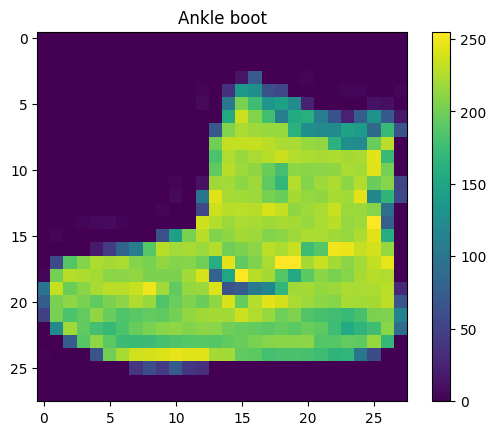

In [8]:
plt.figure()
plt.imshow(X_train[0])#, cmap=plt.cm.binary)
plt.colorbar()
plt.grid(False)
plt.title(class_names[y_train[0]]);

Escala los conjuntos de train y test para que vayan del 0 al 1. No hace falta usar ninguna librería. Con realizar una división en cada conjunto será suficiente.

In [9]:
X_train = X_train / 255.0
X_test = X_test / 255.0

Para verificar que el set de datos está en el formato adecuado y que están listos para construir y entrenar la red, vamos a desplegar las primeras 25 imágenes del *training set* y despleguemos el nombre de cada clase debajo de cada imagen.

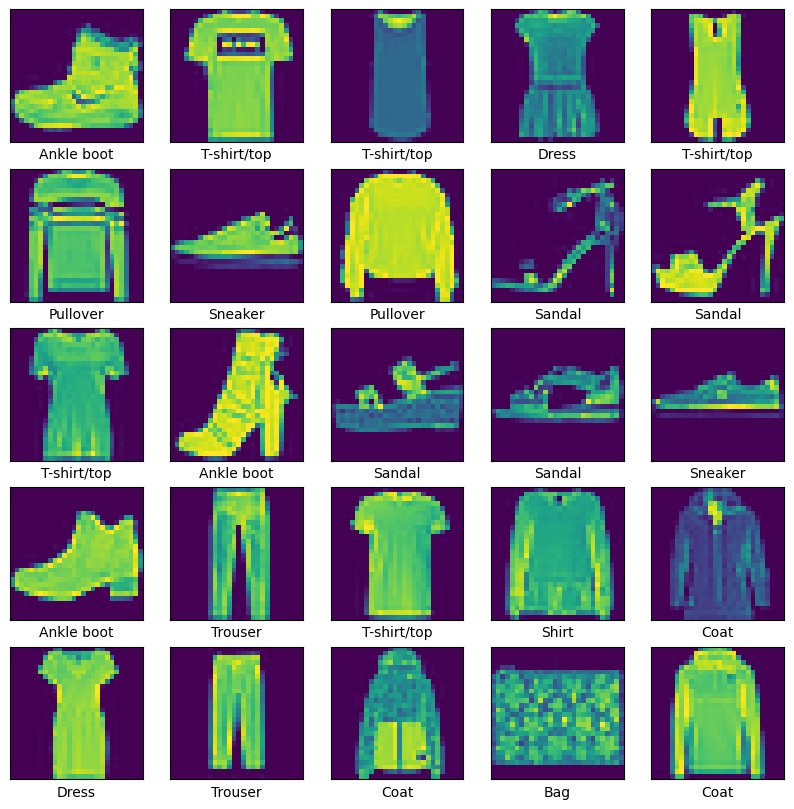

In [10]:
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i])#, cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])
plt.show()

## Construir el Modelo

Construir la red neuronal requiere configurar las capas del modelo y luego compilar el modelo.

### Configurar las Capas
Construye todas las capas del modelo.

In [11]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),   # Capa de entrada: aplana 28x28 → 784
    keras.layers.Dense(300, activation='relu'),    # Capa oculta de 300 neuronas
    keras.layers.Dense(10, activation='softmax')   # Capa de salida: 10 clases
])

### Compila el modelo

Antes de que el modelo este listo para entrenar , se necesitan algunas configuraciones más. Estas son agregadas durante el paso de compilacion del modelo:

* *Loss function* —Esto mide que tan exacto es el modelo durante el entrenamiento. Quiere minimizar esta función para dirigir el modelo en la dirección adecuada.
* *Optimizer* — Esto es cómo el modelo aprende basado en el set de datos que ve y la función de pérdida.
* *Metrics* — Se usan para monitorear los pasos de entrenamiento y de pruebas.


Como es un problema de clasificación multiclase, tendrás que usar `sparse_categorical_crossentropy` como función de coste. En cuanto a las métricas, usa simplemente `accuracy`.

In [12]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

## Entrenar el Modelo
Empieza entrenándolo con 10 epochs. Prueba con más

In [14]:
history = model.fit(X_train, y_train, batch_size = 128, epochs=10, validation_split=0.1)

Epoch 1/10
422/422 [==============================] - 2s 4ms/step - loss: 0.2262 - accuracy: 0.9166 - val_loss: 0.2262 - val_accuracy: 0.9135
Epoch 2/10
422/422 [==============================] - 2s 4ms/step - loss: 0.2228 - accuracy: 0.9167 - val_loss: 0.2348 - val_accuracy: 0.9107
Epoch 3/10
422/422 [==============================] - 2s 4ms/step - loss: 0.2115 - accuracy: 0.9226 - val_loss: 0.2317 - val_accuracy: 0.9123
Epoch 4/10
422/422 [==============================] - 2s 4ms/step - loss: 0.2062 - accuracy: 0.9234 - val_loss: 0.2462 - val_accuracy: 0.9073
Epoch 5/10
422/422 [==============================] - 2s 4ms/step - loss: 0.1964 - accuracy: 0.9273 - val_loss: 0.2422 - val_accuracy: 0.9073
Epoch 6/10
422/422 [==============================] - 2s 4ms/step - loss: 0.1923 - accuracy: 0.9293 - val_loss: 0.2438 - val_accuracy: 0.9133
Epoch 7/10
422/422 [==============================] - 2s 4ms/step - loss: 0.1842 - accuracy: 0.9318 - val_loss: 0.2441 - val_accuracy: 0.9075
Epoch 

In [15]:
model.fit(X_train, y_train, batch_size = 128, epochs=50, validation_split=0.1)

Epoch 1/50
422/422 [==============================] - 2s 4ms/step - loss: 0.1628 - accuracy: 0.9401 - val_loss: 0.2505 - val_accuracy: 0.9082
Epoch 2/50
422/422 [==============================] - 2s 4ms/step - loss: 0.1598 - accuracy: 0.9409 - val_loss: 0.2453 - val_accuracy: 0.9143
Epoch 3/50
422/422 [==============================] - 2s 4ms/step - loss: 0.1545 - accuracy: 0.9431 - val_loss: 0.2539 - val_accuracy: 0.9085
Epoch 4/50
422/422 [==============================] - 2s 4ms/step - loss: 0.1481 - accuracy: 0.9459 - val_loss: 0.2609 - val_accuracy: 0.9052
Epoch 5/50
422/422 [==============================] - 2s 4ms/step - loss: 0.1460 - accuracy: 0.9464 - val_loss: 0.2491 - val_accuracy: 0.9105
Epoch 6/50
422/422 [==============================] - 2s 4ms/step - loss: 0.1438 - accuracy: 0.9464 - val_loss: 0.2689 - val_accuracy: 0.9022
Epoch 7/50
422/422 [==============================] - 2s 4ms/step - loss: 0.1366 - accuracy: 0.9506 - val_loss: 0.2576 - val_accuracy: 0.9042
Epoch 

## Evaluar Accuracy
Prueba el rendimiento del modelo con los datos de test

In [16]:
results = model.evaluate(X_test, y_test, verbose=2)
print(f'\nTest accuracy: {results[1]:.4f}')

313/313 - 1s - loss: 0.5779 - accuracy: 0.8922 - 794ms/epoch - 3ms/step

Test accuracy: 0.8922


## Hacer predicciones

Con el modelo entrenado puedes usarlo para hacer predicciones sobre imagenes.

In [25]:
y_pred = model.predict(X_test)

313/313 [==============================] - 1s 2ms/step


El modelo ha predicho la etiqueta para cada imagen en el set de datos de *test* (prueba). Miremos la primera prediccion:

In [18]:
print('Predicción:', class_names[np.argmax(y_pred[0])])
print('Real:', class_names[y_test[0]])

Predicción: Ankle boot
Real: Ankle boot


*Una* prediccion es un array de 10 numeros. Estos representan el nivel de "confianza" del modelo sobre las imagenes de cada uno de los 10 articulos de moda/ropa. Puedes revisar cual tiene el nivel mas alto de confianza:

In [19]:
def plot_image(i, predictions_array, true_label, img):
  predictions_array, true_label, img = predictions_array, true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap=plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color=color)

def plot_value_array(i, predictions_array, true_label):
  predictions_array, true_label = predictions_array, true_label[i]
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

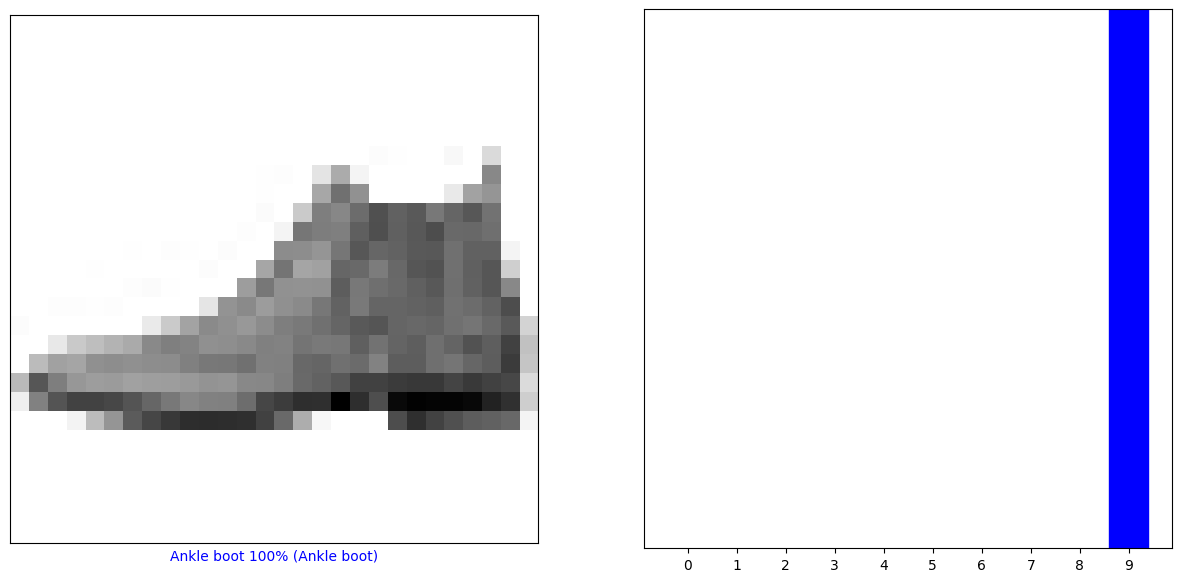

In [20]:
i = 0
plt.figure(figsize=(15,7))
plt.subplot(1,2,1)
plot_image(i, y_pred[i], y_test, X_test)
plt.subplot(1,2,2)
plot_value_array(i, y_pred[i], y_test)

Entonces, el modelo tiene mayor confianza que esta imagen es un bota de tobillo "ankle boot" o `class_names[9]`. Examinando las etiquetas de *test* o de pruebas muestra que esta clasificación es correcta:

**Grafica** esto para poder ver todo el set de la prediccion de las 10 clases.

Miremos la imagen [0], sus predicciones y el array de predicciones. Las etiquetas de predicción correctas estan en azul y las incorrectas están en rojo. El número entrega el porcentaje (sobre 100) para la etiqueta predicha.

Vamos a graficar multiples imagenes con sus predicciones. Notese que el modelo puede estar equivocado aun cuando tiene mucha confianza.

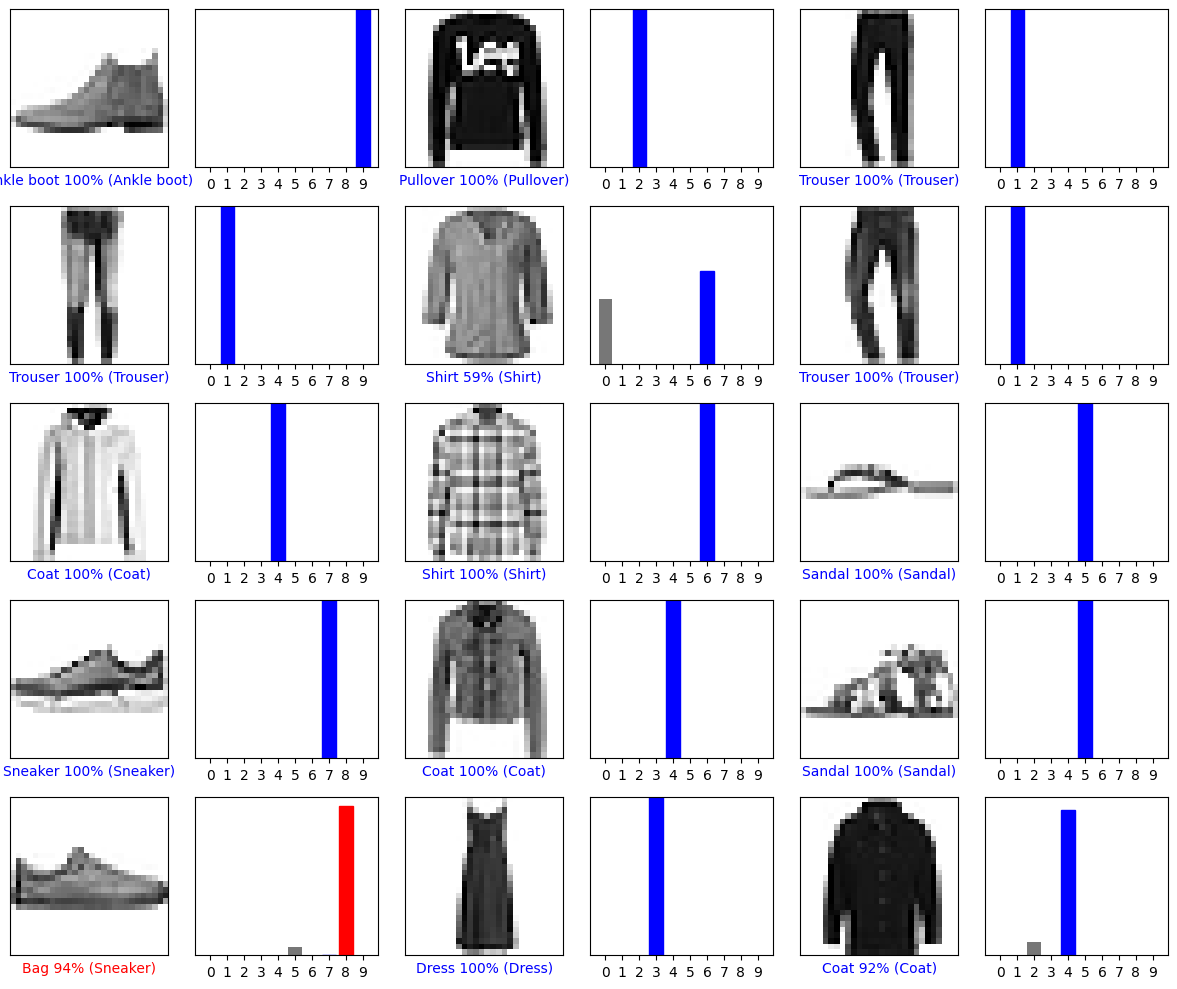

In [21]:
num_rows = 5
num_cols = 3
num_images = num_rows * num_cols

plt.figure(figsize=(2 * 2 * num_cols, 2 * num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 1)
    plot_image(i, y_pred[i], y_test, X_test)
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 2)
    plot_value_array(i, y_pred[i], y_test)
plt.tight_layout()
plt.show()

Evalúa tu modelo con una matriz de confusión e interprétala.

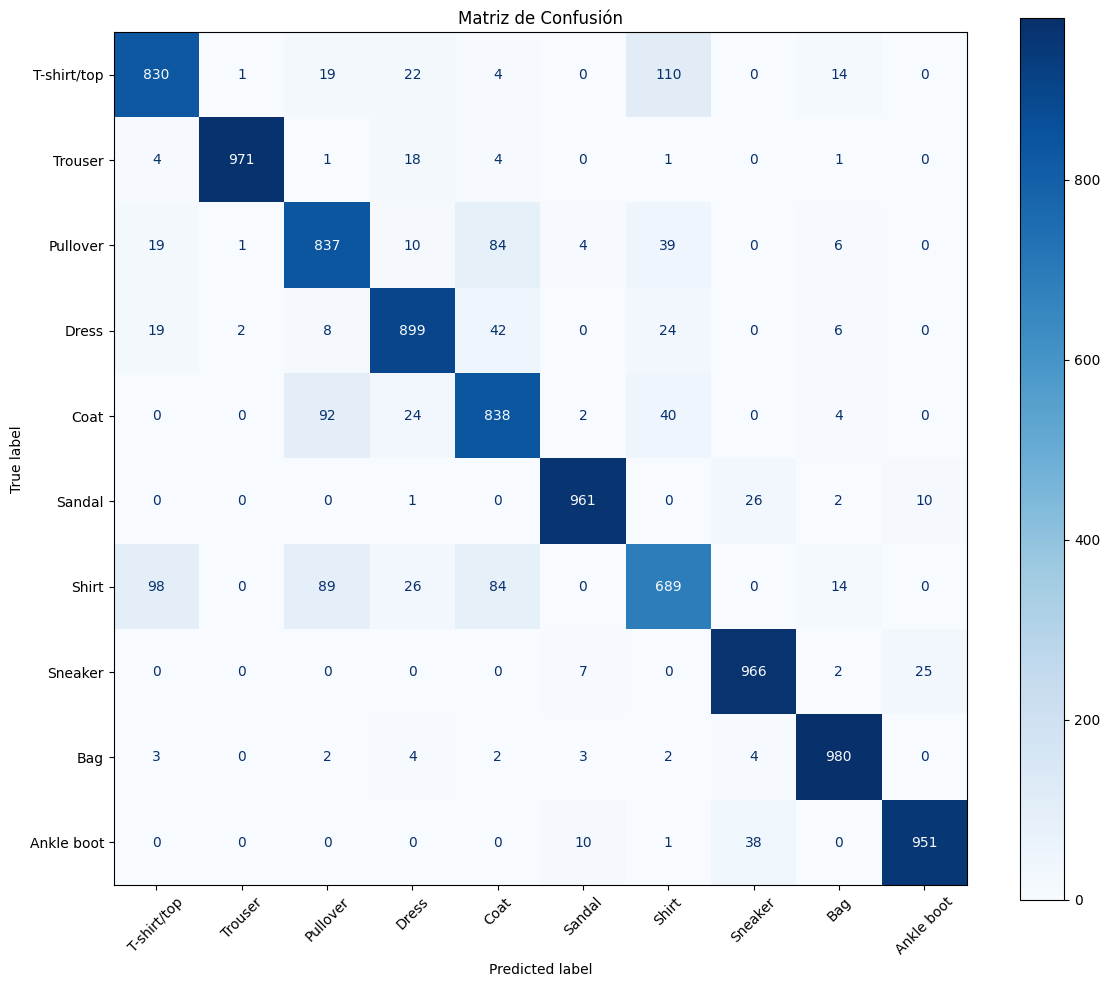

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(ax=ax, xticks_rotation=45, cmap='Blues')
plt.title('Matriz de Confusión')
plt.tight_layout();

Finalmente, usamos el modelo entrenado para hacer una prediccion sobre una única imagen.

In [23]:
img = X_test[0]

img_batch = np.expand_dims(img, 0)

prediction = model.predict(img_batch)

print("Clase predicha:", class_names[np.argmax(prediction[0])])
print("Clase real:    ", class_names[y_test[0]])

1/1 [==============================] - 0s 44ms/step
Clase predicha: Ankle boot
Clase real:     Ankle boot
